In [1]:
#install sqlite3 and pandas
import sqlite3
import pandas as pd

In [2]:
gene_names = pd.read_csv("Gene_names.txt", header=None)
#reading in the gene_names file, specifying no header
gene_names = gene_names[0].tolist() #turning the values generated in the unnamed column into a list
gene_names #print list

['PADI2',
 'HSPB7',
 'PLA2G2A',
 'AGMAT',
 'FABP3',
 'FCN3',
 'SERINC2',
 'MASP2',
 'STMN1',
 'NBL1',
 'LDLRAD2',
 'RBP7',
 'SLC2A5',
 'FBXO2',
 'MXRA8',
 'ANKRD65',
 'CDC42',
 'EPHB2',
 'PRKCZ-AS1',
 'HSPG2',
 'PHACTR4',
 'CASP9',
 'ATAD3B',
 'KIAA2013',
 'AURKAIP1']

In [3]:
con = sqlite3.connect("hg19.sqlite") #connect to sqlite database
c = con.cursor() # create pointer/cursor object to interact with db

In [4]:
placeholders = ", ".join(["?" for _ in gene_names])
#list comprehension - for every item in gene_names, store it as "?"
# and join the "?" into a list with a comma and a space after each one

#subselect to extract specific columns from refGene and partition (split into smaller bins) the items based on their name2
#order the partitioned items and assign rownumber to each
#subselect for the refGene rows with a name2 that matches with the genes in the gene_names.txt file that was converted to a list
#store the select with its subselect as a sql_query and extract selected cols with information from first row of each partitioned group
sql_query="""SELECT name, name2,
        chrom, strand, txStart, txEnd 
    FROM (
        SELECT refGene.name, refGene.name2,
        refGene.chrom, refGene.strand, refGene.txStart, refGene.txEnd,
        ROW_NUMBER() OVER (PARTITION BY refGene.name2) AS rn 
        FROM refGene
        WHERE refGene.name2 IN ({})
        )
    WHERE rn = 1;""".format(placeholders)
    #.format informs python of placeholders (represented as curly brackets), where the ?'s should be in the sql_query 

results=pd.read_sql_query(sql_query, con, params=(*gene_names,)) #pandas expects the placeholders to be ?'s 
#provide pandas with sql_query that accepts dynamic variables, db connection, unpacked gene_names
#for the ?'s placed by the format(placeholders), the query runs through the code, replacing the ? with the gene_name

#display dataframe
results

,name,name2,chrom,strand,txStart,txEnd
0,NM_024758,AGMAT,chr1,-,15898193,15911546
1,NM_001375660,ANKRD65,chr1,-,1353799,1356656
2,NM_031921,ATAD3B,chr1,+,1407144,1433228
3,NM_017900,AURKAIP1,chr1,-,1309115,1310587
4,NM_001278054,CASP9,chr1,-,15817895,15850940
5,NM_001791,CDC42,chr1,+,22379201,22427853
6,NM_004442,EPHB2,chr1,+,23037330,23247993
7,NM_004102,FABP3,chr1,-,31838099,31845923
8,NM_012168,FBXO2,chr1,-,11708443,11714486
9,NM_003665,FCN3,chr1,-,27695600,27701315


In [5]:
refGenesCoor=pd.DataFrame(results) #save the results as dataframe refGenesCoor
#load values from refGenesCoor dataframe into sql db; if the data already exists, replace w new data; w/o index
refGenesCoor.to_sql('refGenesCoor', con, if_exists="replace", index=False)
#write the refGenesCoor dataframe to a csv file with the provided name, providing the table with header w list of col names 
df = refGenesCoor.to_csv('Kalkidan_Tadese_part1.csv', index=False, header=["name", "name2", "chrom", "strand", "txStart", "txEnd"])

In [6]:
#to query every table in the db, the table names are stored in a list
# then using a for loop, each table of the list of tables in the dataframe are individually queried
#the tissue-specific table with aligned RNA-seq reads replaces the {} since python expects a list for each placeholder

tbllist = ["burgeRnaSeqGemMapperAlignBrain","burgeRnaSeqGemMapperAlignBreast","burgeRnaSeqGemMapperAlignAdipose",
        "burgeRnaSeqGemMapperAlignColon","burgeRnaSeqGemMapperAlignHeart", "burgeRnaSeqGemMapperAlignLiver"]

#initialize empty list to store df resulting from each tissue query
maindf = []

#sql query is stored in sql_query2 variable that contains the query to count reads
#each tissue table contains genomic coordinates that align to different genes in refGenesCoor dataframe
#to compare the individual gene data to the reads of each table, we groupby the gene's refGenes data to call and compare each count 
#join tissue table with new {tissue}_ReadCount with refGenesCoor table
for x in tbllist: 
        y = x[25:] #chop off the first part of the tissue name 'burgeRnaSeqGemMapperAlign' to save counts as Brain_ReadCount later
        sql_query2="""SELECT refGenesCoor.name, refGenesCoor.name2,
             refGenesCoor.chrom, refGenesCoor.strand, refGenesCoor.txStart, refGenesCoor.txEnd,
             COUNT(*) AS {}_readCount
             FROM refGenesCoor
             JOIN {} ON
             refGenesCoor.txStart <= {}.chromStart and
             refGenesCoor.txEnd >= {}.chromEnd and
             refGenesCoor.chrom = {}.chrom
             GROUP BY  refGenesCoor.name, refGenesCoor.name2,
                         refGenesCoor.chrom, refGenesCoor.strand, 
                         refGenesCoor.txStart, refGenesCoor.txEnd ;""".format(y,x,x,x,x) #.format informs python of placeholders (represented as curly brackets)
        maindf.append(pd.read_sql_query(sql_query2,con))
#placeholders - for the first curly bracket - y = have it name new "Tissue"_ReadCount, x's - rest refer to db table
    #run sql query, append result as df to maindf list
       

# combines resulting tissue dataframes in maindf list into a single dataframe
ReadCount_df = pd.concat(maindf)


In [7]:
ReadCount_df

,name,name2,chrom,strand,txStart,txEnd,Brain_readCount,Breast_readCount,Adipose_readCount,Colon_readCount,Heart_readCount,Liver_readCount
0,NM_001013693,LDLRAD2,chr1,+,22138757,22151716,51.0,NaN,NaN,NaN,NaN,NaN
1,NM_001145454,STMN1,chr1,-,26210669,26232910,4091.0,NaN,NaN,NaN,NaN,NaN
2,NM_001278054,CASP9,chr1,-,15817895,15850940,84.0,NaN,NaN,NaN,NaN,NaN
3,NM_001278166,NBL1,chr1,+,19974103,19984949,1859.0,NaN,NaN,NaN,NaN,NaN
4,NM_001349683,HSPB7,chr1,-,16340523,16344538,15.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
20,NM_032348,MXRA8,chr1,-,1288070,1293935,NaN,NaN,NaN,NaN,NaN,54.0
21,NM_052960,RBP7,chr1,+,10057285,10076079,NaN,NaN,NaN,NaN,NaN,50.0
22,NM_138346,KIAA2013,chr1,-,11979647,11986484,NaN,NaN,NaN,NaN,NaN,338.0
23,NM_178865,SERINC2,chr1,+,31886059,31907525,NaN,NaN,NaN,NaN,NaN,1981.0


In [8]:
#pandas fillna to handle null values, replacing the NA for 0
#fillna returns new df; when parameter set to true, fillna replaces NA values in original dataframe
ReadCount_df.fillna(0, inplace=True)
#display dataframe with replaced NA values
ReadCount_df

,name,name2,chrom,strand,txStart,txEnd,Brain_readCount,Breast_readCount,Adipose_readCount,Colon_readCount,Heart_readCount,Liver_readCount
0,NM_001013693,LDLRAD2,chr1,+,22138757,22151716,51.0,0.0,0.0,0.0,0.0,0.0
1,NM_001145454,STMN1,chr1,-,26210669,26232910,4091.0,0.0,0.0,0.0,0.0,0.0
2,NM_001278054,CASP9,chr1,-,15817895,15850940,84.0,0.0,0.0,0.0,0.0,0.0
3,NM_001278166,NBL1,chr1,+,19974103,19984949,1859.0,0.0,0.0,0.0,0.0,0.0
4,NM_001349683,HSPB7,chr1,-,16340523,16344538,15.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
20,NM_032348,MXRA8,chr1,-,1288070,1293935,0.0,0.0,0.0,0.0,0.0,54.0
21,NM_052960,RBP7,chr1,+,10057285,10076079,0.0,0.0,0.0,0.0,0.0,50.0
22,NM_138346,KIAA2013,chr1,-,11979647,11986484,0.0,0.0,0.0,0.0,0.0,338.0
23,NM_178865,SERINC2,chr1,+,31886059,31907525,0.0,0.0,0.0,0.0,0.0,1981.0


In [9]:
# drop duplicate rows from the original dataframe
ReadCount_df.drop_duplicates(inplace=True)
#write the dataframe to a named csv file; index not wanted, so index set as false
ReadCount_df.to_csv('Kalkidan_Tadese_part2.csv', index=True)

In [10]:
#store the ReadCount/result columns in a new list
tissue_columns = [col for col in ReadCount_df.columns if "_readCount" in col]
df_1NF = ReadCount_df.melt(
    id_vars=["name2", "chrom", "strand", "txStart", "txEnd"], #keep gene coors info, including gene name, name2 etc
    value_vars=tissue_columns, #melt tissue columns; ReadCount is a repeat group/bin
    var_name="Tissue", #store the melted column in a column called Tissue and store the expression values in a column called ReadCount
    value_name="ReadCount")

df_1NF #display melted dataframe
# post-melt modification - remove the _readCount suffix from tissues 
df_1NF["Tissue"] = df_1NF["Tissue"].str.replace("_readCount", "")
df_1NF = df_1NF.loc[df_1NF["ReadCount"] != 0] #select rows with non-zero values in the ReadCount column
df_1NF = df_1NF.sort_values(by="name2", ascending=True).drop_duplicates().reset_index(drop=True)
#sort the select non-zero readcount rows by their name2 in asc order (alphabetically) 
#reset index without inserting it as a column in a new dataframe
#drop=False would convert row indices into a column

#display sorted/modified dataframe
df_1NF

,name2,chrom,strand,txStart,txEnd,Tissue,ReadCount
0,AGMAT,chr1,-,15898193,15911546,Heart,1.0
1,AGMAT,chr1,-,15898193,15911546,Liver,1048.0
2,AGMAT,chr1,-,15898193,15911546,Breast,25.0
3,AGMAT,chr1,-,15898193,15911546,Adipose,7.0
4,AGMAT,chr1,-,15898193,15911546,Colon,71.0
...,...,...,...,...,...,...,...
144,STMN1,chr1,-,26210669,26232910,Heart,136.0
145,STMN1,chr1,-,26210669,26232910,Liver,26.0
146,STMN1,chr1,-,26210669,26232910,Colon,331.0
147,STMN1,chr1,-,26210669,26232910,Breast,123.0


In [11]:
df_1NF.to_sql('CleanReadCountTbl', con, if_exists="replace", index=False)
# to_sql() function to write records stored in df_1NF dataframe to a sql database, provided the connection with con
#if_exists parameter ensures that the table is dropped and created anew if the table already exists
#Index = False; parameter indicating that we do not want to create a table index with a new column added for it

149

In [12]:
#saving the modified dataframe to another variable for part 3
df2 = df_1NF

#defining function to calculate mean and standard deviation --> to calculate z-score
#x.mean and x.std are pandas built-in functions; using paranthesis to order operations
#z-score = (individual data point - mean)/standard deviation - calculating z-score as means of normalizing expression values
def mean_time_series(x):
    return (x-x.mean())/x.std()

# storing the expression values in this "expvalues" col of the dataframe
#grouping by name2 to calculate cumulative statistics of the ReadCount values -- calculate mean, stddev for the read counts of a given gene
df2['expvalues'] = df_1NF.groupby("name2")["ReadCount"].transform(mean_time_series)
#transform applies row by row - on a #/collection of rows
#df2.drop(columns = "mean")

#reshape dataframe - pivots dataframe from long to wide format
df2_pivoted = df2.pivot(index = ["name2", "chrom", "strand", "txStart", "txEnd"], values = 'expvalues', columns = 'Tissue').reset_index()
#name2 is how it indexes the new pivoted table (once the tissue column is unmelted -- one column ==> 6 columns) -- keep this fixed as a reference (index expects individual column or list of columns)
#values = columns we want to keep the same

In [13]:
df2_pivoted.dtypes
#display the datatypes of dataframe

Tissue
name2       object
chrom       object
strand      object
txStart      int64
txEnd        int64
Adipose    float64
Brain      float64
Breast     float64
Colon      float64
Heart      float64
Liver      float64
dtype: object

In [14]:
GeneNorm=pd.DataFrame(df2_pivoted) #save the results as dataframe GeneNorm
#write the GeneNorm dataframe to a csv file with my name, do not add an index
df = GeneNorm.to_csv('Kalkidan_Tadese_part3.csv', index=False)

In [15]:
#import seaborn library for data visualization
import seaborn as sns

#melt -- reshape from wide to long format - individual tissue columns are converted to variables
df_1NF = df2_pivoted.melt(
    id_vars=["name2", "chrom", "strand", "txStart", "txEnd"],  # Keep only relevant gene info columns
    value_vars=["Adipose", "Brain", "Breast", "Colon", "Heart", "Liver"],  # Melt only tissue-related columns
    var_name="Tissue",  # Convert column names into "Tissue" values
    value_name="Expvalues"  # Store z-score
)

#display modified df
df_1NF

,name2,chrom,strand,txStart,txEnd,Tissue,Expvalues
0,AGMAT,chr1,-,15898193,15911546,Adipose,-0.453977
1,ANKRD65,chr1,-,1353799,1356656,Adipose,-0.246570
2,ATAD3B,chr1,+,1407144,1433228,Adipose,0.190883
3,AURKAIP1,chr1,-,1309115,1310587,Adipose,1.379095
4,CASP9,chr1,-,15817895,15850940,Adipose,0.739048
...,...,...,...,...,...,...,...
145,PRKCZ-AS1,chr1,-,2113232,2115314,Liver,-0.891534
146,RBP7,chr1,+,10057285,10076079,Liver,-0.543593
147,SERINC2,chr1,+,31886059,31907525,Liver,1.515080
148,SLC2A5,chr1,-,9095164,9129694,Liver,-0.921533


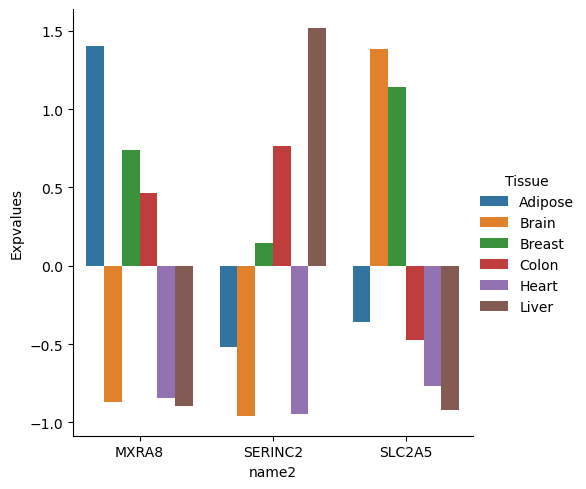

In [16]:
# store in plotgens a list of the genes we want to visualize
plotgens = ["MXRA8", "SERINC2", "SLC2A5"]

#filter dataframe for rows with genes that have name2 that is in the target genes list
fdf = df_1NF[df_1NF["name2"].isin(plotgens)]
#first [] produces boolean array in dataframe when condition is true/false
#second [] to df filters for the true instances

#create a categorical bar plot comparing normalized expression across tissues
genebarplt = sns.catplot(data=fdf, x="name2", y="Expvalues", hue='Tissue', kind="bar")
#save barplot as png
genebarplt.savefig("Kalkidan_Tadese_plot.png")

In [17]:
con.close()